PCA - eigenfaces.

In [1]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Downloads the Olivetti face data to `./data` folder in current working directory as .pkz cache file, loads into memory as a bunch/dictionary object.
olivetti = fetch_olivetti_faces(data_home="./data")

In [3]:
# Now inspect the bunch object by keys.
# More information here:
# .images is a 3D Numpy array of 400 observations of 2D (64, 64) face images, which can be viewed as such
# .data is a 2D Numpy array of 400 observations of flattened 1D (4066,) vectors, data we need to pass to PCA.
# .target is a 1D Numpy array of 400 labels 0-39, referring to 40 faces, 10 images per face.
print(olivetti.keys())
print(olivetti.data.shape)
print(olivetti.images.shape)
print(olivetti.target.shape)

dict_keys(['data', 'images', 'target', 'DESCR'])
(400, 4096)
(400, 64, 64)
(400,)


In [4]:
# For the face images, each element of the (64, 64) image is a float between [0,1].
# This float describes *grayscale* pixel intensity.
print(olivetti.images.dtype)
print(olivetti.images.min())
print(olivetti.images.max())

float32
0.0
1.0


In [5]:
# Assign unlabelled data, images, and labels to names.
W = olivetti.data
faces = olivetti.images
y = olivetti.target

PCA - Exploratory data analysis of images via visualisation.

Noting that our uncentred data matrix $\mathbf{W} \in \mathbb{R}^{n \times d}$, with $n = 400$ observations and $d = 4096$ pixel intensity features, we are in a high-dimensional regime with $d > n$ and $d / n = 4096 / 400 \approx 10$. 

* A good thing to note as a point of departure from the iris toy dataset is that this is image data, not tabular data, and so attempting a pairs plot, or a correlation heatmap on 4096 "pixel features" makes no sense.
* Instead our main tool is to visualise directly.

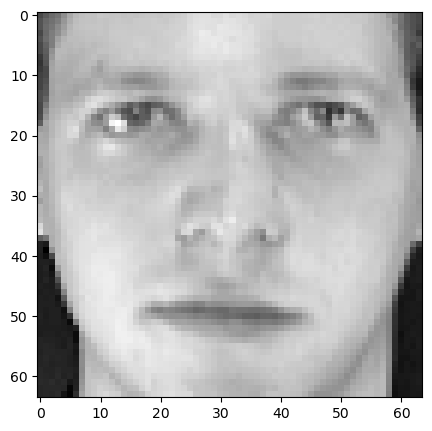

In [6]:
# Display one face using `.matploylib.imshow()`. # The parameter `cmap="gray` declares to `.imshow()` that images are grayscale pixel floats, otherwise error.
fig, ax = plt.subplots(figsize=(5,5))
plt.imshow(faces[0], cmap="gray")

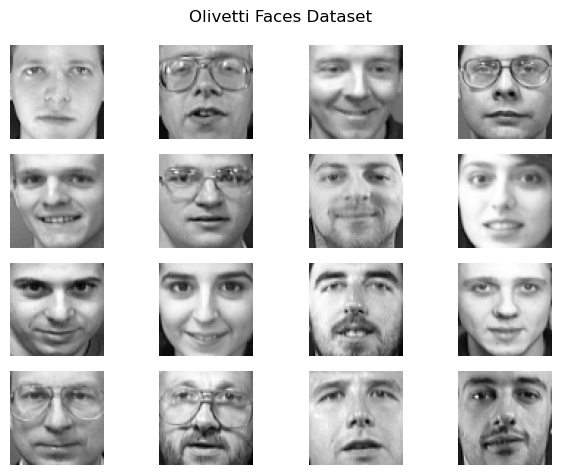

In [ ]:
# Create a panel of images showing 16 unique faces, iterating through the 400 observations of 40 faces 10 at a time.
fig, axes = plt.subplots(4,4)
for i, ax in enumerate(axes.ravel()):
    ax.imshow(faces[i * 10], cmap="gray")
    ax.axis("off")
plt.suptitle("Olivetti Faces Dataset")
plt.tight_layout()
plt.show()

PCA - Mean centering.

To anchor this in the theory at population level, we have a $d$-dimensional random vector $W \in \mathbb{R}^d$ with mean $\mu_W$.  For PCA, we instead work with the mean-centred random vector $X \in \mathbb{R}^d$, where $X = W - \mu_W$, so that the mean of $X$ is $\mu = 0$, and its variance-covariance matrix is $\boldsymbol{\Sigma} = \text{Cov}(X) = \mathbb{E}[XX^{\top}]$.

Our Olivetti faces data consists of an observation matrix $\boldsymbol{W} \in \mathbb{R}^{n \times d}$ with $n = 400$ observations and $d = 4096$ pixel-features. This consists of the observation vectors $w_i \in \mathbb{R}^d$ of the $Y$ stored as rows $w_i^{\top}$ of this matrix. With the sample mean vector $\overline{w} = (1 / n)\sum^n_{i=1} w_i$, then we have that our mean-centred observation matrix is,

$$\mathbf{X}\in \mathbb{R}^{n \times d} = \mathbf{W} - \bf{1}\overline{w}^T$$

In [8]:
# Centre, but do not standardise the data by sample standard deviation.
scaler = StandardScaler(with_mean=True, with_std=False)
X = scaler.fit_transform(W)
X_mean = scaler.mean_

In [9]:
# Reshaping the flattened 1D (4096, ) vectors yields the demeaned face images.
faces_centred = X.reshape(400, 64, 64)
mean_face = X_mean.reshape(64,64)

PCA - Visualising mean-centred faces and the average face.

Below is the "average face" that arises after reshaping $\bar{w} \in \mathbb{R}^d$ to a 2D $(64, 64)$ pixel image. Looks like a computer generated forensic sketch for serial killers...

* This is a visually striking example of expectations and sample means being statistical constructs that are summaries of distributions, not necessarily members of them - in the same way the "average person" has one ovary and one testis, or the "average family" has 1.8 children.
* In that respect, we can see that whilst the "average face" has facial features common to all faces in the dataset e.g. eyes, nose, mouth, these features are blurred via averaging in a way that none of the actual faces exhibit. 

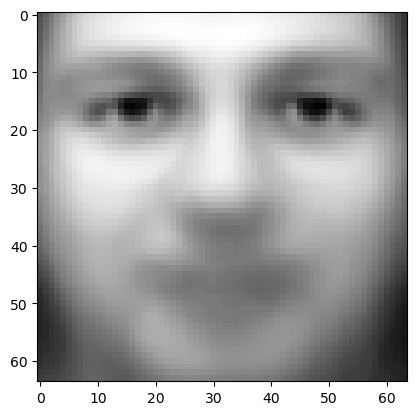

In [10]:
# Show the "average face".
plt.imshow(mean_face,cmap="gray")

Below are the "mean-centred faces" that arise after reshaping the observation vector $x_i \in \R^{d}$ to be a 2D (64,64) pixel image. A little devilish - as the iris and pupil colouring has been stripped away, amongst other things.

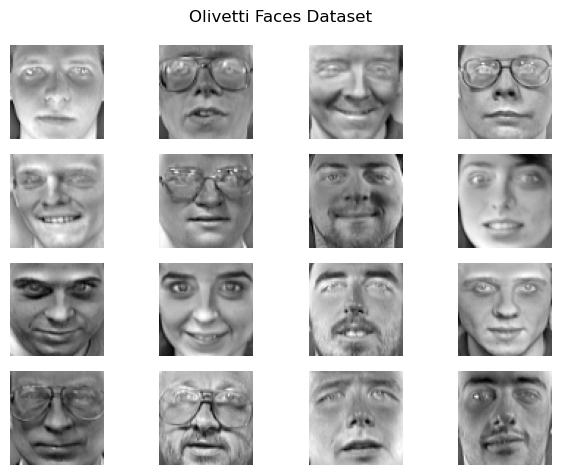

In [12]:
# Show the mean-centred faces.
fig, axes = plt.subplots(4,4)
for i, ax in enumerate(axes.ravel()):
    # The parameter `cmap="gray"` declares to `.imshow()` that images are grayscale!
    ax.imshow(scaler.mean_.reshape(64, 64), cmap="gray")
    ax.imshow(faces_centred[i * 10], cmap="gray")
    ax.axis("off")
plt.suptitle("Olivetti Faces Dataset")
plt.tight_layout()
plt.show()

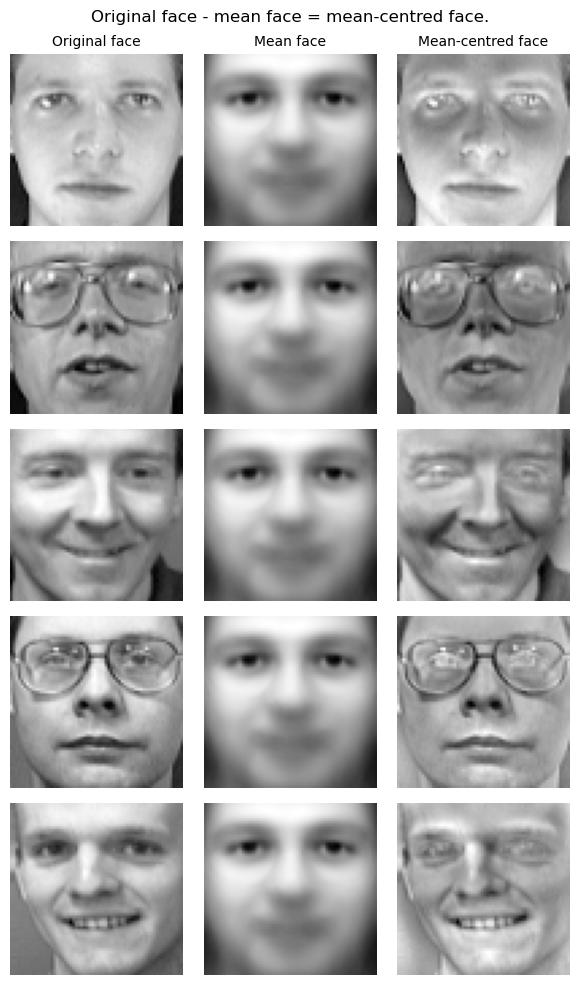

In [ ]:
# A visual illustration of sample-mean centering for PCA.
fig, axes = plt.subplots(5,3, figsize=(6,10))
col_titles = ["Original face", "Mean face", "Mean-centred face"]
for ax, title in zip(axes[0,:], col_titles):
    ax.set_title(title, fontsize=10)

# Recall that if you do choose to iterate over Numpy arrays, it does so over rows, i.e. axis-0.
for i, ax_row in enumerate(axes):
    ax_row[0].imshow(faces[i * 10], cmap="gray")
    ax_row[1].imshow(mean_face, cmap="gray")
    ax_row[2].imshow(faces_centred[i * 10], cmap="gray")

    for ax in ax_row:
        ax.axis("off")

plt.suptitle("Original face - mean face = mean-centred face.")
plt.tight_layout()
plt.show()

PCA - Choosing number of components.



In [ ]:
pca_full = PCA(n_components=400)
pca_full.fit(X)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",400
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SV

In [ ]:
scree_df = pd.DataFrame({"Principal component": [f"PC{i+1}" for i in range(400)],
                         "Explained variance ratio": pca_full.explained_variance_ratio_,
                         "Cumulative explained variance ratio": np.cumsum(pca_full.explained_variance_ratio_)})
scree_df.iloc[:71,:]

,Principal component,Explained variance ratio,Cumulative explained variance ratio
0,PC1,0.238127,0.238127
1,PC2,0.139940,0.378067
2,PC3,0.079686,0.457753
3,PC4,0.049983,0.507736
4,PC5,0.036099,0.543835
...,...,...,...
66,PC67,0.001369,0.901615
67,PC68,0.001340,0.902954
68,PC69,0.001309,0.904263
69,PC70,0.001287,0.905551


In [ ]:
pca = PCA(n_components=400)
proj_X = pca.fit_transform(X)
reconstr_X = pca.inverse_transform(proj_X)

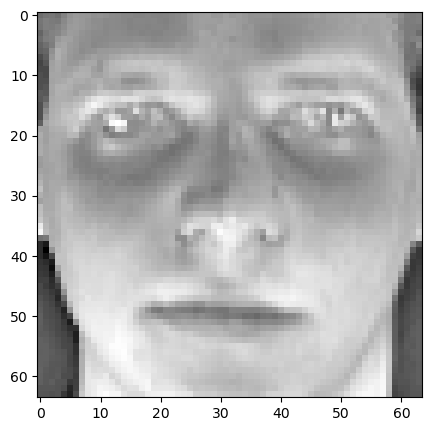

In [ ]:
fig, ax = plt.subplots(figsize=(5,5))
x_0 = reconstr_X[0].reshape(64,64)
plt.imshow(x_0, cmap="gray")